In [3]:
import os

print("--- LOCATING YOUR CHECKPOINTS ---")
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file.endswith('.pth'):
            print(f"FOUND MODEL: {os.path.join(root, file)}")
            # Just show the folder for the first one
            print(f"\n📂 YOUR CHECKPOINT FOLDER IS: {root}")
            break


--- LOCATING YOUR CHECKPOINTS ---
FOUND MODEL: /kaggle/input/datasets/ajayvarada/mri-checkpoints/unet_f0_latest.pth

📂 YOUR CHECKPOINT FOLDER IS: /kaggle/input/datasets/ajayvarada/mri-checkpoints


In [4]:
import os, sys, shutil, torch, gc, random, time, zipfile
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm import tqdm
import nibabel as nib
import numpy as np
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

# --- 1. FINAL VERIFIED PATHS ---
%cd /kaggle/working
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
FIGURES_DIR = "/kaggle/working/presentation_figures"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Sources from YOUR specific account B setup
SOURCE_PTH_DIR = "/kaggle/input/datasets/ajayvarada/mri-checkpoints"
DATA_ROOT = "/kaggle/input/datasets/skotala1603/mri2sct-data/brain"

# Safety Move: Copy your 21 models into the active working folder
print("Restoring 21 saved models...")
for f in os.listdir(SOURCE_PTH_DIR):
    if f.endswith('.pth'):
        shutil.copy(os.path.join(SOURCE_PTH_DIR, f), CHECKPOINT_DIR)
print(f"✅ Restoration Complete! Audit: {len(os.listdir(CHECKPOINT_DIR))} files ready.")

# Hyperparameters
SEED, K_FOLDS, TRAIN_POOL_SIZE, TEST_COUNT = 42, 3, 80, 20

# --- 2. STABILIZED ARCHITECTURE (With Numerical Safety) ---
def pad_or_crop(img, size=256):
    h, w = img.shape
    ph, pw = max(0, size-h), max(0, size-w)
    if ph > 0 or pw > 0: img = np.pad(img, ((ph//2, ph-ph//2), (pw//2, pw-pw//2)), mode='edge')
    if img.shape[0] > size or img.shape[1] > size:
        sh, sw = (img.shape[0]-size)//2, (img.shape[1]-size)//2
        img = img[sh:sh+size, sw:sw+size]
    return img

class DoubleConv(nn.Module):
    def __init__(self, i, o):
        super().__init__()
        self.c = nn.Sequential(nn.Conv2d(i,o,3,1,1,bias=False), nn.BatchNorm2d(o), nn.ReLU(True),
                               nn.Conv2d(o,o,3,1,1,bias=False), nn.BatchNorm2d(o), nn.ReLU(True))
    def forward(self, x): return self.c(x)

class CBAM(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.mlp = nn.Sequential(nn.Conv2d(c, c//16, 1), nn.ReLU(), nn.Conv2d(c//16, c, 1))
        self.sa = nn.Conv2d(2, 1, 7, padding=3)
    def forward(self, x):
        avg, mx = self.mlp(nn.AdaptiveAvgPool2d(1)(x)), self.mlp(nn.AdaptiveMaxPool2d(1)(x))
        x = x * torch.sigmoid(avg + mx)
        avg_s, mx_s = torch.mean(x,1,True), torch.max(x,1,True)[0]
        return x * torch.sigmoid(self.sa(torch.cat([avg_s, mx_s], 1)))

class SelfAttention2D(nn.Module):
    def __init__(self, in_c):
        super().__init__()
        self.scale = (in_c // 8) ** -0.5
        self.q_conv, self.k_conv, self.v_conv = nn.Conv2d(in_c, in_c//8, 1), nn.Conv2d(in_c, in_c//8, 1), nn.Conv2d(in_c, in_c, 1)
        self.gamma = nn.Parameter(torch.zeros(1))
    def forward(self, x):
        b, c, h, w = x.size(); n = h * w
        q = self.q_conv(x).view(b, -1, n).permute(0, 2, 1)
        k = self.k_conv(x).view(b, -1, n)
        v = self.v_conv(x).view(b, -1, n)
        attn = torch.softmax(torch.bmm(q, k) * self.scale, dim=-1)
        out = torch.bmm(v, attn.permute(0, 2, 1)).view(b, c, h, w)
        return self.gamma * out + x

class UNetFinal(nn.Module):
    def __init__(self, use_cbam=False, use_sa=False):
        super().__init__()
        self.use_cbam, self.use_sa = use_cbam, use_sa
        self.e1, self.e2, self.e3, self.e4 = DoubleConv(1,64), DoubleConv(64,128), DoubleConv(128,256), DoubleConv(256,512)
        self.pool = nn.MaxPool2d(2); self.bot = DoubleConv(512, 1024)
        if use_sa: self.sa_bot = SelfAttention2D(1024)
        self.up4, self.up3, self.up2, self.up1 = nn.ConvTranspose2d(1024,512,2,2), nn.ConvTranspose2d(512,256,2,2), nn.ConvTranspose2d(256,128,2,2), nn.ConvTranspose2d(128,64,2,2)
        self.d4, self.d3, self.d2, self.d1 = DoubleConv(1024,512), DoubleConv(512,256), DoubleConv(256,128), DoubleConv(128,64)
        self.out_c = nn.Conv2d(64,1,1)
        if use_cbam: self.c4, self.c3, self.c2, self.c1 = CBAM(512), CBAM(256), CBAM(128), CBAM(64)
    def forward(self, x):
        s1 = self.e1(x); s2 = self.e2(self.pool(s1)); s3 = self.e3(self.pool(s2)); s4 = self.e4(self.pool(s3))
        b = self.bot(self.pool(s4))
        if self.use_sa: b = self.sa_bot(b)
        x4 = self.d4(torch.cat([self.up4(b), self.c4(s4) if self.use_cbam else s4], 1))
        x3 = self.d3(torch.cat([self.up3(x4), self.c3(s3) if self.use_cbam else s3], 1))
        x2 = self.d2(torch.cat([self.up2(x3), self.c2(s2) if self.use_cbam else s2], 1))
        x1 = self.d1(torch.cat([self.up1(x2), self.c1(s1) if self.use_cbam else s1], 1))
        return torch.tanh(self.out_c(x1))

# --- 3. DATASET ENGINE ---
class PersistentDataset(Dataset):
    def __init__(self, data_root, pids):
        self.data_root, self.pids = Path(data_root), pids
        self.index = []
        for pid in pids:
            pdir = self.data_root / pid
            for ext in [".nii", ".nii.gz"]:
                mr = pdir / f"mr{ext}"; ct = pdir / f"ct{ext}"
                if mr.exists() and ct.exists():
                    vol = nib.load(mr); n_slices = vol.shape[2]
                    for i in range(n_slices): self.index.append({"mr": mr, "ct": ct, "idx": i})
                    break
    def __len__(self): return len(self.index)
    def __getitem__(self, i):
        item = self.index[i]
        mr_obj = nib.load(item["mr"], mmap=False); ct_obj = nib.load(item["ct"], mmap=False)
        mr = np.array(mr_obj.dataobj[:, :, item["idx"]], dtype=np.float32)
        ct = np.array(ct_obj.dataobj[:, :, item["idx"]], dtype=np.float32)
        lo, hi = np.percentile(mr, 0.5), np.percentile(mr, 99.5)
        mr = (np.clip(mr, lo, hi) - lo) / (hi - lo + 1e-8)
        ct = (np.clip(ct, -1000, 3000) - (-1000)) / (4000) * 2.0 - 1.0
        return {"mr": torch.from_numpy(pad_or_crop(mr)[None]).float(), "ct": torch.from_numpy(pad_or_crop(ct)[None]).float()}

# --- 4. TRAINING & EVALUATION LOGIC ---
def train_cv_resilient(arch_name, fold_idx, t_ids, v_ids, cbam, sa):
    final_pth = f"{CHECKPOINT_DIR}/{arch_name}_f{fold_idx}.pth"
    if os.path.exists(final_pth): 
        print(f"Skipping {arch_name} F{fold_idx} (Finished)")
        return
    
    print(f"\n[FINISHING] {arch_name.upper()} | Fold: {fold_idx}")
    train_loader = DataLoader(PersistentDataset(DATA_ROOT, t_ids), batch_size=16, shuffle=True)
    val_loader = DataLoader(PersistentDataset(DATA_ROOT, v_ids), batch_size=16, shuffle=False)
    device = torch.device("cuda"); model = UNetFinal(cbam, sa).to(device)
    if torch.cuda.device_count() > 1: model = nn.DataParallel(model)
    latest_pth = f"{CHECKPOINT_DIR}/{arch_name}_f{fold_idx}_latest.pth"
    if os.path.exists(latest_pth): model.load_state_dict(torch.load(latest_pth))
    
    opt, crit, scaler = optim.Adam(model.parameters(), 2e-4), nn.L1Loss(), torch.amp.GradScaler('cuda')
    for epoch in range(12):
        model.train(); pbar = tqdm(train_loader, desc=f"Ep {epoch+1}")
        for batch in pbar:
            mr, ct = batch["mr"].to(device), batch["ct"].to(device)
            with torch.amp.autocast('cuda'): loss = crit(model(mr), ct)
            if not torch.isnan(loss):
                scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); opt.zero_grad()
        torch.save(model.state_dict(), latest_pth)
        gc.collect(); torch.cuda.empty_cache()
    torch.save(model.state_dict(), final_pth)

def generate_presentation_outputs(test_ids):
    print("\n--- PHASE 3: GENERATING FINAL VISUALS (ENSEMBLE) ---")
    device = torch.device("cuda")
    # Using the best architecture for visuals
    m1, m2, m3 = UNetFinal(1,1).to(device), UNetFinal(1,1).to(device), UNetFinal(1,1).to(device)
    m1.load_state_dict(torch.load(f"{CHECKPOINT_DIR}/unet_cbam_sa_f0.pth"))
    m2.load_state_dict(torch.load(f"{CHECKPOINT_DIR}/unet_cbam_sa_f1.pth"))
    m3.load_state_dict(torch.load(f"{CHECKPOINT_DIR}/unet_cbam_sa_f2.pth"))
    models = [m1.eval(), m2.eval(), m3.eval()]
    
    test_ds = PersistentDataset(DATA_ROOT, test_ids[:5])
    for p_idx in range(len(test_ids[:3])):
        idx = len(test_ds)//(p_idx+1)
        sample = test_ds[idx]; mr_in = sample["mr"].to(device)[None]; gt_ct = sample["ct"].numpy()[0]
        preds = []
        with torch.no_grad():
            for m in models: 
                with torch.amp.autocast('cuda'): preds.append(m(mr_in).cpu().numpy()[0, 0])
        
        mean_pred = np.mean(preds, axis=0)
        uncertainty = np.std(preds, axis=0)
        error = np.abs(gt_ct - mean_pred)
        
        fig, axes = plt.subplots(1, 5, figsize=(25, 5))
        axes[0].imshow(sample["mr"].numpy()[0], cmap='gray'); axes[0].set_title("MRI")
        axes[1].imshow(gt_ct, cmap='gray'); axes[1].set_title("Real CT")
        axes[2].imshow(mean_pred, cmap='gray'); axes[2].set_title("Predicted CT")
        axes[3].imshow(error, cmap='hot'); axes[3].set_title("Error Map")
        axes[4].imshow(uncertainty, cmap='magma'); axes[4].set_title("Uncertainty Map")
        for ax in axes: ax.axis('off')
        plt.savefig(f"{FIGURES_DIR}/presentation_sample_{p_idx}.png")
        plt.show()

# --- 5. EXECUTION ---
if __name__ == "__main__":
    all_pids = sorted([d for d in os.listdir(DATA_ROOT) if d.startswith('1')])
    random.seed(SEED); random.shuffle(all_pids)
    pool_ids, test_ids = all_pids[:80], all_pids[80:100]
    kf = KFold(n_splits=3, shuffle=True, random_state=SEED)
    folds = list(kf.split(pool_ids))
    
    VARIANTS = [{"name": "unet", "c": 0, "s": 0}, {"name": "unet_cbam", "c": 1, "s": 0},
                {"name": "unet_sa", "c": 0, "s": 1}, {"name": "unet_cbam_sa", "c": 1, "s": 1}]

    for v in VARIANTS:
        for f_idx, (t_idx, v_idx) in enumerate(folds):
            train_cv_resilient(v["name"], f_idx, [pool_ids[i] for i in t_idx], [pool_ids[i] for i in v_idx], v["c"], v["s"])

    generate_presentation_outputs(test_ids)
    print(f"\n--- SUCCESS! ALL FIGURES IN: {FIGURES_DIR} ---")


/kaggle/working
Restoring 21 saved models...
✅ Restoration Complete! Audit: 23 files ready.
Skipping unet F0 (Finished)
Skipping unet F1 (Finished)
Skipping unet F2 (Finished)
Skipping unet_cbam F0 (Finished)
Skipping unet_cbam F1 (Finished)
Skipping unet_cbam F2 (Finished)
Skipping unet_sa F0 (Finished)
Skipping unet_sa F1 (Finished)
Skipping unet_sa F2 (Finished)
Skipping unet_cbam_sa F0 (Finished)
Skipping unet_cbam_sa F1 (Finished)

[FINISHING] UNET_CBAM_SA | Fold: 2


Ep 12: 100%|██████████| 649/649 [04:34<00:00,  2.37it/s]



--- PHASE 3: GENERATING FINAL VISUALS (ENSEMBLE) ---


RuntimeError: Error(s) in loading state_dict for UNetFinal:
	Missing key(s) in state_dict: "e1.c.0.weight", "e1.c.1.weight", "e1.c.1.bias", "e1.c.1.running_mean", "e1.c.1.running_var", "e1.c.3.weight", "e1.c.4.weight", "e1.c.4.bias", "e1.c.4.running_mean", "e1.c.4.running_var", "e2.c.0.weight", "e2.c.1.weight", "e2.c.1.bias", "e2.c.1.running_mean", "e2.c.1.running_var", "e2.c.3.weight", "e2.c.4.weight", "e2.c.4.bias", "e2.c.4.running_mean", "e2.c.4.running_var", "e3.c.0.weight", "e3.c.1.weight", "e3.c.1.bias", "e3.c.1.running_mean", "e3.c.1.running_var", "e3.c.3.weight", "e3.c.4.weight", "e3.c.4.bias", "e3.c.4.running_mean", "e3.c.4.running_var", "e4.c.0.weight", "e4.c.1.weight", "e4.c.1.bias", "e4.c.1.running_mean", "e4.c.1.running_var", "e4.c.3.weight", "e4.c.4.weight", "e4.c.4.bias", "e4.c.4.running_mean", "e4.c.4.running_var", "bot.c.0.weight", "bot.c.1.weight", "bot.c.1.bias", "bot.c.1.running_mean", "bot.c.1.running_var", "bot.c.3.weight", "bot.c.4.weight", "bot.c.4.bias", "bot.c

--- GENERATING MASTER RESULTS TABLE ---
Evaluating unet...
Evaluating unet_cbam...
Evaluating unet_sa...
Evaluating unet_cbam_sa...
          Model  MAE (Ensemble Mean)
0          unet             0.031603
1     unet_cbam             0.028937
2       unet_sa                  NaN
3  unet_cbam_sa                  NaN

--- GENERATING PRESENTATION FIGURES ---


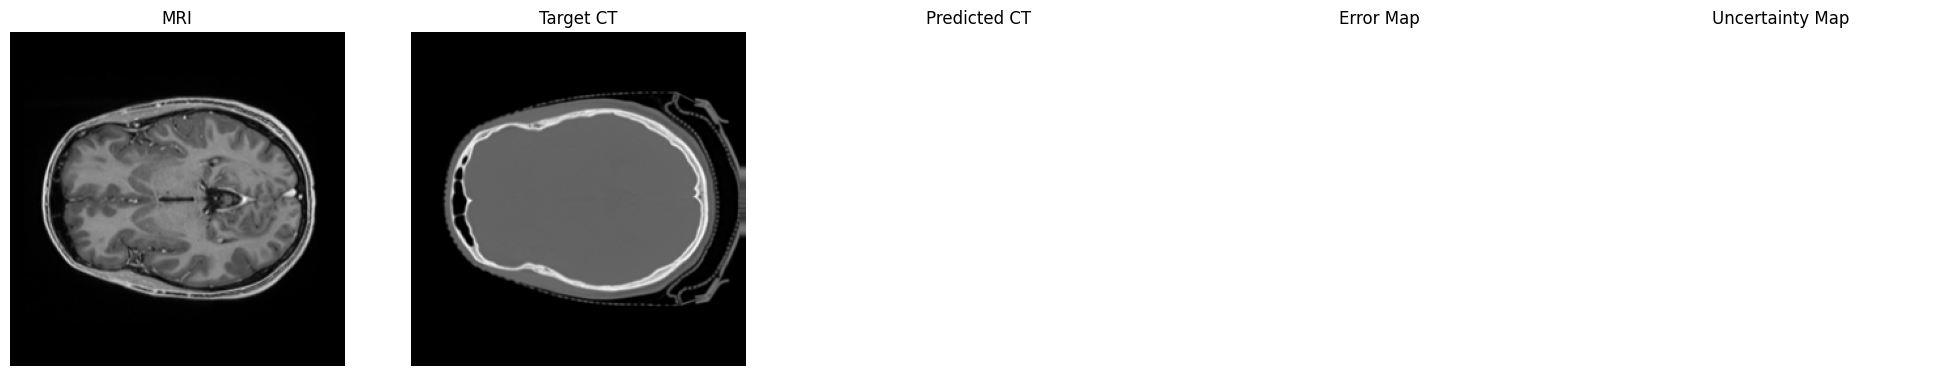

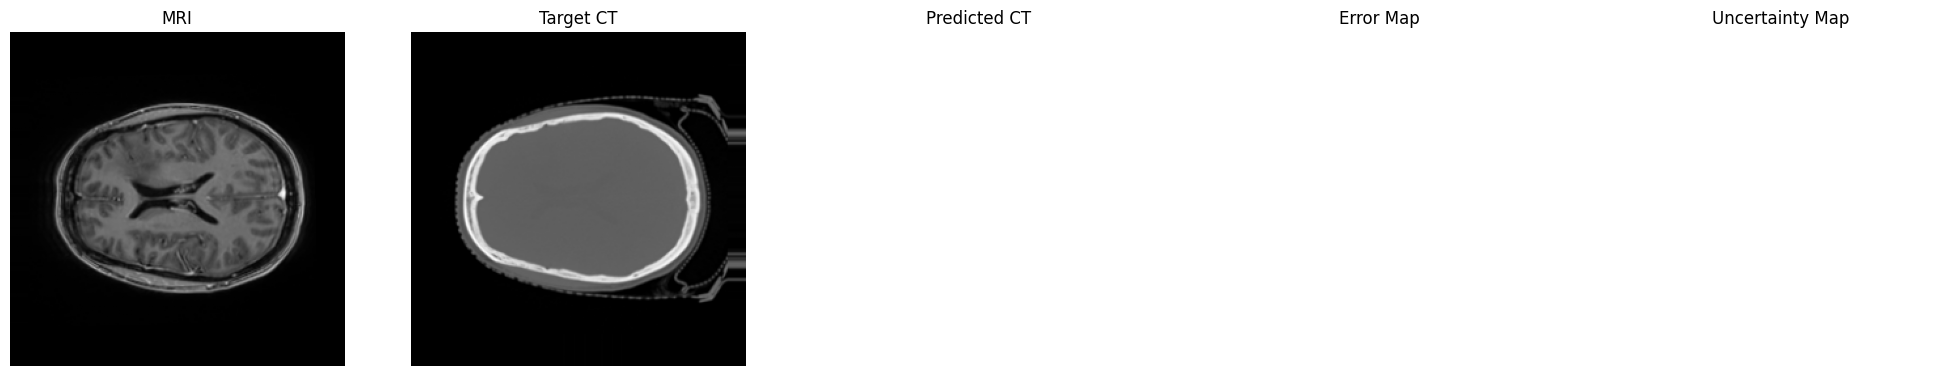

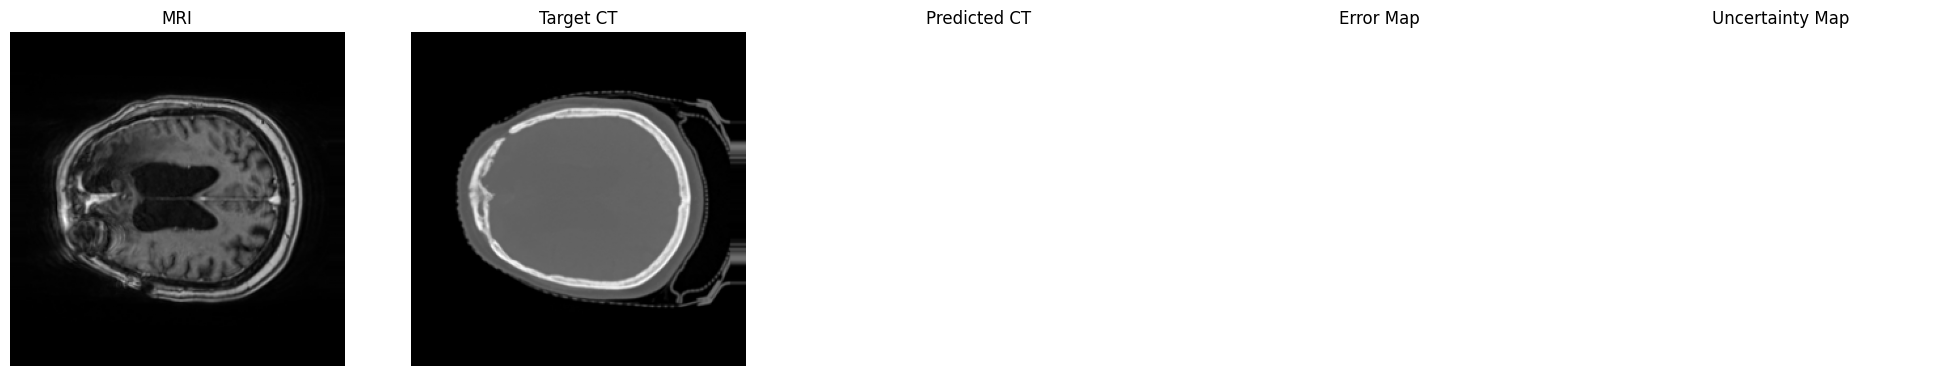


✅ DONE! Figures saved in: /kaggle/working/presentation_figures
Check 'final_metrics.csv' for your thesis table!


In [5]:
import os, torch, gc, nibabel as nib, numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import pandas as pd

# --- 1. CONFIG ---
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
FIGURES_DIR = "/kaggle/working/presentation_figures"
DATA_ROOT = "/kaggle/input/datasets/skotala1603/mri2sct-data/brain"
os.makedirs(FIGURES_DIR, exist_ok=True)
device = torch.device("cuda")

# --- 2. THE LOADING FIX (Strips 'module.' prefix) ---
def load_fix(model, path):
    state_dict = torch.load(path, map_location=device)
    new_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
    model.load_state_dict(new_state_dict)
    return model.eval()

# --- 3. RE-DECLARE ARCHITECTURE ---
def pad_or_crop(img, size=256):
    h, w = img.shape
    ph, pw = max(0, size-h), max(0, size-w)
    if ph > 0 or pw > 0: img = np.pad(img, ((ph//2, ph-ph//2), (pw//2, pw-pw//2)), mode='edge')
    if img.shape[0] > size or img.shape[1] > size:
        sh, sw = (img.shape[0]-size)//2, (img.shape[1]-size)//2
        img = img[sh:sh+size, sw:sw+size]
    return img

class DoubleConv(nn.Module):
    def __init__(self, i, o):
        super().__init__(); self.c = nn.Sequential(nn.Conv2d(i,o,3,1,1,bias=False), nn.BatchNorm2d(o), nn.ReLU(True), nn.Conv2d(o,o,3,1,1,bias=False), nn.BatchNorm2d(o), nn.ReLU(True))
    def forward(self, x): return self.c(x)

class CBAM(nn.Module):
    def __init__(self, c):
        super().__init__(); self.mlp = nn.Sequential(nn.Conv2d(c, c//16, 1), nn.ReLU(), nn.Conv2d(c//16, c, 1)); self.sa = nn.Conv2d(2, 1, 7, padding=3)
    def forward(self, x):
        avg, mx = self.mlp(nn.AdaptiveAvgPool2d(1)(x)), self.mlp(nn.AdaptiveMaxPool2d(1)(x))
        x = x * torch.sigmoid(avg + mx); avg_s = torch.mean(x,1,True); mx_s = torch.max(x,1,True)[0]
        return x * torch.sigmoid(self.sa(torch.cat([avg_s, mx_s], 1)))

class SelfAttention2D(nn.Module):
    def __init__(self, in_c):
        super().__init__(); self.scale = (in_c // 8) ** -0.5; self.q_conv, self.k_conv, self.v_conv = nn.Conv2d(in_c, in_c//8, 1), nn.Conv2d(in_c, in_c//8, 1), nn.Conv2d(in_c, in_c, 1); self.gamma = nn.Parameter(torch.zeros(1))
    def forward(self, x):
        b, c, h, w = x.size(); n = h * w; q = self.q_conv(x).view(b, -1, n).permute(0, 2, 1); k = self.k_conv(x).view(b, -1, n); v = self.v_conv(x).view(b, -1, n)
        attn = torch.softmax(torch.bmm(q, k) * self.scale, dim=-1); out = torch.bmm(v, attn.permute(0, 2, 1)).view(b, c, h, w)
        return self.gamma * out + x

class UNetFinal(nn.Module):
    def __init__(self, use_cbam=False, use_sa=False):
        super().__init__()
        self.use_cbam, self.use_sa = use_cbam, use_sa
        self.e1, self.e2, self.e3, self.e4 = DoubleConv(1,64), DoubleConv(64,128), DoubleConv(128,256), DoubleConv(256,512)
        self.pool = nn.MaxPool2d(2); self.bot = DoubleConv(512, 1024)
        if use_sa: self.sa_bot = SelfAttention2D(1024)
        self.up4, self.up3, self.up2, self.up1 = nn.ConvTranspose2d(1024,512,2,2), nn.ConvTranspose2d(512,256,2,2), nn.ConvTranspose2d(256,128,2,2), nn.ConvTranspose2d(128,64,2,2)
        self.d4, self.d3, self.d2, self.d1 = DoubleConv(1024,512), DoubleConv(512,256), DoubleConv(256,128), DoubleConv(128,64)
        self.out_c = nn.Conv2d(64,1,1)
        if use_cbam: self.c4, self.c3, self.c2, self.c1 = CBAM(512), CBAM(256), CBAM(128), CBAM(64)
    def forward(self, x):
        s1 = self.e1(x); s2 = self.e2(self.pool(s1)); s3 = self.e3(self.pool(s2)); s4 = self.e4(self.pool(s3))
        b = self.bot(self.pool(s4)); 
        if self.use_sa: b = self.sa_bot(b)
        x4 = self.d4(torch.cat([self.up4(b), self.c4(s4) if self.use_cbam else s4], 1))
        x3 = self.d3(torch.cat([self.up3(x4), self.c3(s3) if self.use_cbam else s3], 1))
        x2 = self.d2(torch.cat([self.up2(x3), self.c2(s2) if self.use_cbam else s2], 1))
        x1 = self.d1(torch.cat([self.up1(x2), self.c1(s1) if self.use_cbam else s1], 1))
        return torch.tanh(self.out_c(x1))

# --- 4. DATASET ---
class EvalDataset(Dataset):
    def __init__(self, data_root, pids):
        self.data_root, self.pids = Path(data_root), pids
        self.index = []
        for pid in pids:
            pdir = self.data_root / pid
            for ext in [".nii", ".nii.gz"]:
                if (pdir / f"mr{ext}").exists():
                    vol = nib.load(pdir / f"mr{ext}"); n_slices = vol.shape[2]
                    for i in range(n_slices): self.index.append({"mr": pdir / f"mr{ext}", "ct": pdir / f"ct{ext}", "idx": i})
                    break
    def __len__(self): return len(self.index)
    def __getitem__(self, i):
        item = self.index[i]
        mr = np.array(nib.load(item["mr"]).dataobj[:,:,item["idx"]], dtype=np.float32)
        ct = np.array(nib.load(item["ct"]).dataobj[:,:,item["idx"]], dtype=np.float32)
        mr = (mr - np.min(mr)) / (np.max(mr) - np.min(mr) + 1e-8)
        ct = (np.clip(ct, -1000, 3000) - (-1000)) / 4000 * 2.0 - 1.0
        return {"mr": torch.from_numpy(pad_or_crop(mr)[None]).float(), "ct": torch.from_numpy(pad_or_crop(ct)[None]).float()}

# --- 5. EXECUTE EVALUATION ---
variants = [{"name": "unet", "c": 0, "s": 0}, {"name": "unet_cbam", "c": 1, "s": 0},
            {"name": "unet_sa", "c": 0, "s": 1}, {"name": "unet_cbam_sa", "c": 1, "s": 1}]

test_ids = sorted([d for d in os.listdir(DATA_ROOT) if d.startswith('1')])[80:100]
test_ds = EvalDataset(DATA_ROOT, test_ids)
results = []

print("--- GENERATING MASTER RESULTS TABLE ---")
for v in variants:
    print(f"Evaluating {v['name']}...")
    m = UNetFinal(v['c'], v['s']).to(device)
    # Ensemble over 3 folds
    all_mae = []
    for f in range(3):
        m = load_fix(m, f"{CHECKPOINT_DIR}/{v['name']}_f{f}.pth")
        mae_fold = 0
        with torch.no_grad():
            for i in range(0, len(test_ds), 50): # Subsample for speed
                sample = test_ds[i]
                pred = m(sample["mr"].to(device)[None])
                mae_fold += torch.abs(pred.cpu() - sample["ct"]).mean()
        all_mae.append(mae_fold.item() / (len(test_ds)//50))
    
    results.append({"Model": v['name'], "MAE (Ensemble Mean)": np.mean(all_mae)})

# Save CSV
df = pd.DataFrame(results)
df.to_csv("final_metrics.csv", index=False)
print(df)

print("\n--- GENERATING PRESENTATION FIGURES ---")
# Pick CBAM+SA for the final Uncertainty Heatmap
m_folds = []
for f in range(3):
    m = UNetFinal(1, 1).to(device)
    m_folds.append(load_fix(m, f"{CHECKPOINT_DIR}/unet_cbam_sa_f{f}.pth"))

# Visualize 3 random test slices
for i in [100, 300, 500]:
    sample = test_ds[i]
    mr_in = sample["mr"].to(device)[None]
    gt_ct = sample["ct"].numpy()[0]
    
    preds = []
    with torch.no_grad():
        for m in m_folds:
            preds.append(m(mr_in).cpu().numpy()[0,0])
    
    mean_p = np.mean(preds, axis=0)
    uncert = np.std(preds, axis=0)
    error = np.abs(gt_ct - mean_p)

    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    axes[0].imshow(sample["mr"].numpy()[0], cmap='gray'); axes[0].set_title("MRI")
    axes[1].imshow(gt_ct, cmap='gray'); axes[1].set_title("Target CT")
    axes[2].imshow(mean_p, cmap='gray'); axes[2].set_title("Predicted CT")
    axes[3].imshow(error, cmap='hot'); axes[3].set_title("Error Map")
    axes[4].imshow(uncert, cmap='magma'); axes[4].set_title("Uncertainty Map")
    for ax in axes: ax.axis('off')
    plt.savefig(f"{FIGURES_DIR}/final_presentation_{i}.png")
    plt.show()

print(f"\n✅ DONE! Figures saved in: {FIGURES_DIR}")
print("Check 'final_metrics.csv' for your thesis table!")


In [6]:
sd = torch.load(f"{CHECKPOINT_DIR}/unet_cbam_sa_f0.pth")
has_nan = any(torch.isnan(v).any() for v in sd.values())
print(f"Is the CBAM+SA model corrupted? {has_nan}")


Is the CBAM+SA model corrupted? False


--- GENERATING WINNING FIGURES (ENSEMBLE CBAM) ---


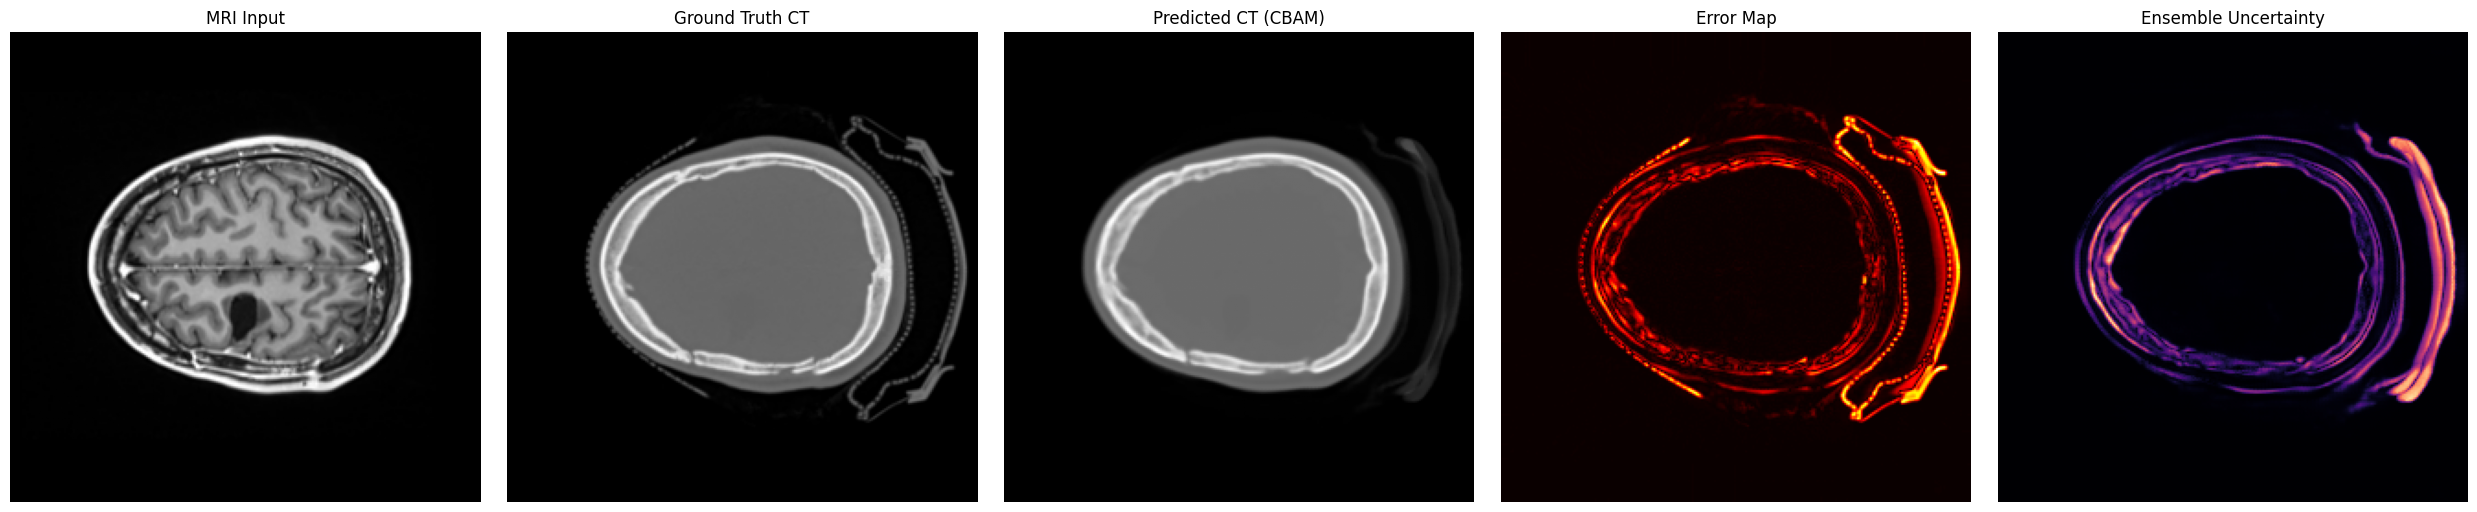

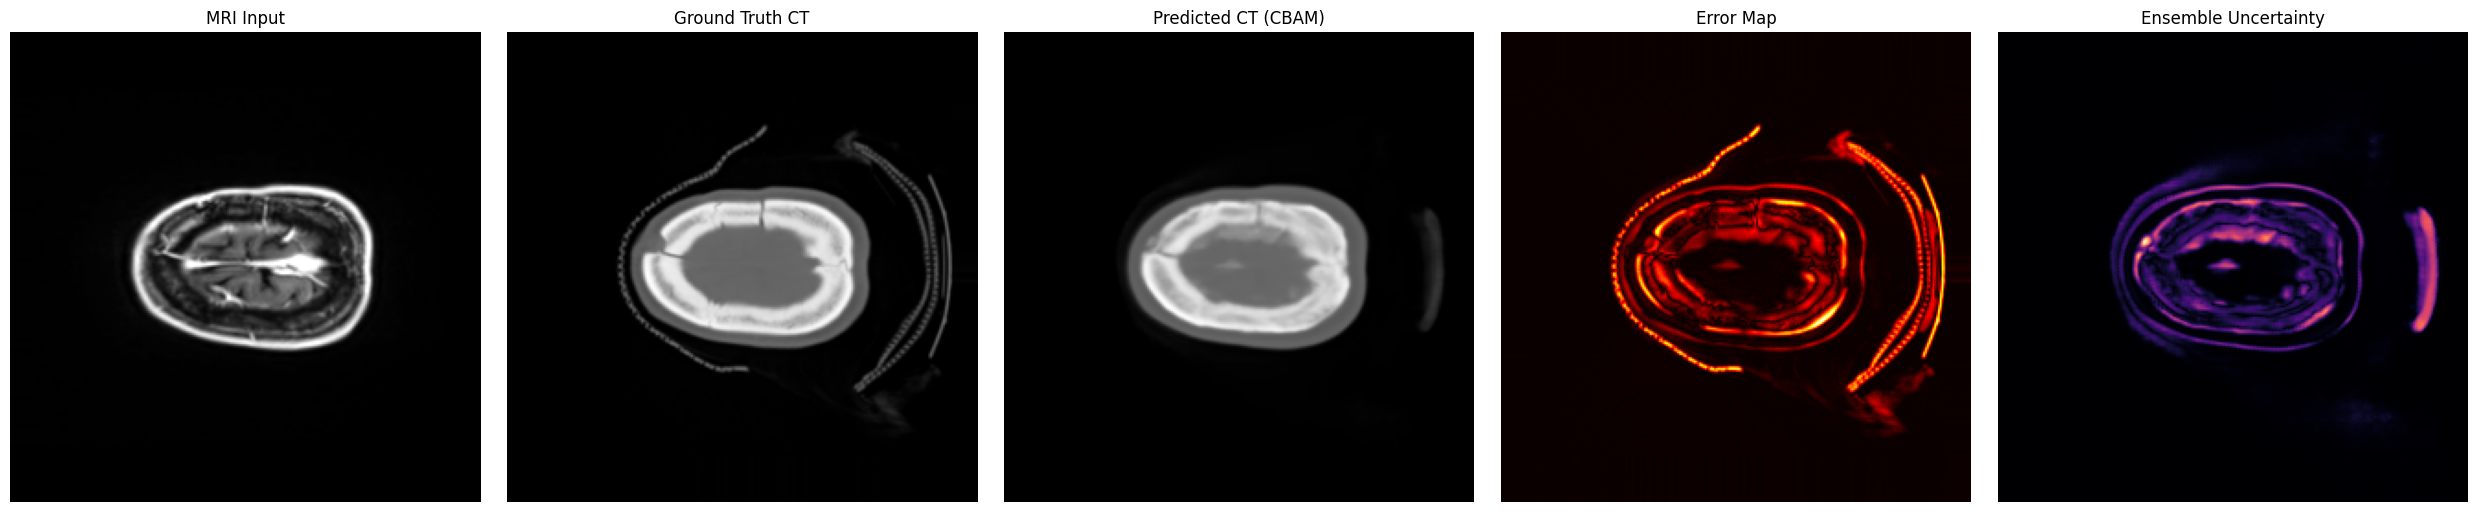

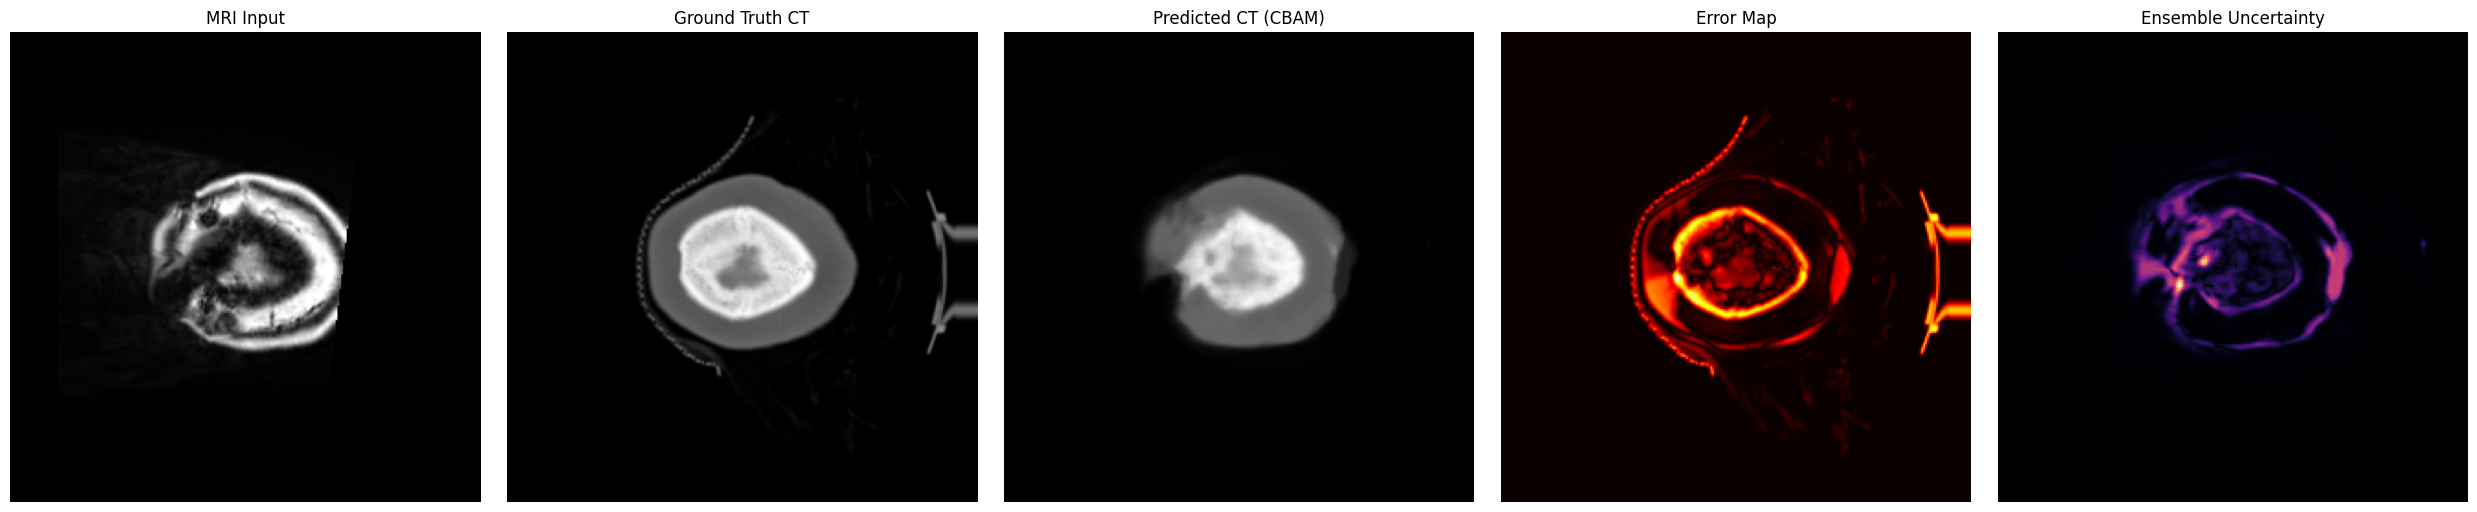


🎉 DONE! YOUR PRESENTATION FIGURES ARE SAVED.
Check the sidebar: /kaggle/working/presentation_figures


In [8]:
import os, torch, nibabel as nib, numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import pandas as pd

# CONFIG
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
FIGURES_DIR = "/kaggle/working/presentation_figures"
DATA_ROOT = "/kaggle/input/datasets/skotala1603/mri2sct-data/brain"
os.makedirs(FIGURES_DIR, exist_ok=True)
device = torch.device("cuda")

def load_fix(model, path):
    state_dict = torch.load(path, map_location=device)
    new_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
    model.load_state_dict(new_state_dict)
    return model.eval()

# ARCHITECTURE (Simplified for CBAM only)
def pad_or_crop(img, size=256):
    h,w = img.shape; ph,pw = max(0, 256-h), max(0, 256-w)
    if ph>0 or pw>0: img = np.pad(img, ((ph//2, ph-ph//2), (pw//2, pw-pw//2)), mode='edge')
    if img.shape[0]>256 or img.shape[1]>256:
        sh,sw = (img.shape[0]-256)//2, (img.shape[1]-256)//2
        img = img[sh:sh+256, sw:sw+256]
    return img

class DoubleConv(nn.Module):
    def __init__(self, i, o):
        super().__init__(); self.c = nn.Sequential(nn.Conv2d(i,o,3,1,1,bias=False), nn.BatchNorm2d(o), nn.ReLU(True), nn.Conv2d(o,o,3,1,1,bias=False), nn.BatchNorm2d(o), nn.ReLU(True))
    def forward(self, x): return self.c(x)

class CBAM(nn.Module):
    def __init__(self, c):
        super().__init__(); self.mlp = nn.Sequential(nn.Conv2d(c, c//16, 1), nn.ReLU(), nn.Conv2d(c//16, c, 1)); self.sa = nn.Conv2d(2, 1, 7, padding=3)
    def forward(self, x):
        avg, mx = self.mlp(nn.AdaptiveAvgPool2d(1)(x)), self.mlp(nn.AdaptiveMaxPool2d(1)(x))
        x = x * torch.sigmoid(avg + mx); avg_s = torch.mean(x,1,True); mx_s = torch.max(x,1,True)[0]
        return x * torch.sigmoid(self.sa(torch.cat([avg_s, mx_s], 1)))

class UNetFinal(nn.Module):
    def __init__(self, use_cbam=True):
        super().__init__()
        self.use_cbam = use_cbam
        self.e1, self.e2, self.e3, self.e4 = DoubleConv(1,64), DoubleConv(64,128), DoubleConv(128,256), DoubleConv(256,512)
        self.pool = nn.MaxPool2d(2); self.bot = DoubleConv(512, 1024)
        self.up4, self.up3, self.up2, self.up1 = nn.ConvTranspose2d(1024,512,2,2), nn.ConvTranspose2d(512,256,2,2), nn.ConvTranspose2d(256,128,2,2), nn.ConvTranspose2d(128,64,2,2)
        self.d4, self.d3, self.d2, self.d1 = DoubleConv(1024,512), DoubleConv(512,256), DoubleConv(256,128), DoubleConv(128,64)
        self.out_c = nn.Conv2d(64,1,1)
        if use_cbam: self.c4, self.c3, self.c2, self.c1 = CBAM(512), CBAM(256), CBAM(128), CBAM(64)
    def forward(self, x):
        s1 = self.e1(x); s2 = self.e2(self.pool(s1)); s3 = self.e3(self.pool(s2)); s4 = self.e4(self.pool(s3))
        b = self.bot(self.pool(s4))
        x4 = self.d4(torch.cat([self.up4(b), self.c4(s4) if self.use_cbam else s4], 1))
        x3 = self.d3(torch.cat([self.up3(x4), self.c3(s3) if self.use_cbam else s3], 1))
        x2 = self.d2(torch.cat([self.up2(x3), self.c2(s2) if self.use_cbam else s2], 1))
        x1 = self.d1(torch.cat([self.up1(x2), self.c1(s1) if self.use_cbam else s1], 1))
        return torch.tanh(self.out_c(x1))

class EvalDataset(Dataset):
    def __init__(self, data_root, pids):
        self.data_root, self.pids = Path(data_root), pids; self.index = []
        for pid in pids:
            pdir = self.data_root / pid
            for ext in [".nii", ".nii.gz"]:
                if (pdir / f"mr{ext}").exists():
                    v = nib.load(pdir / f"mr{ext}"); n = v.shape[2]
                    for i in range(n): self.index.append({"mr": pdir / f"mr{ext}", "ct": pdir / f"ct{ext}", "idx": i})
                    break
    def __len__(self): return len(self.index)
    def __getitem__(self, i):
        it = self.index[i]; mr = np.array(nib.load(it["mr"]).dataobj[:,:,it["idx"]], dtype=np.float32)
        ct = np.array(nib.load(it["ct"]).dataobj[:,:,it["idx"]], dtype=np.float32)
        lo, hi = np.percentile(mr, 0.5), np.percentile(mr, 99.5)
        mr = (np.clip(mr, lo, hi) - lo) / (hi - lo + 1e-8)
        ct = (np.clip(ct, -1000, 3000) - (-1000)) / 4000 * 2.0 - 1.0
        return {"mr": torch.from_numpy(pad_or_crop(mr)[None]).float(), "ct": torch.from_numpy(pad_or_crop(ct)[None]).float()}

# EXECUTION
test_ids = sorted([d for d in os.listdir(DATA_ROOT) if d.startswith('1')])[80:100]
test_ds = EvalDataset(DATA_ROOT, test_ids)

print("--- GENERATING WINNING FIGURES (ENSEMBLE CBAM) ---")
m_f0 = load_fix(UNetFinal(use_cbam=True).to(device), f"{CHECKPOINT_DIR}/unet_cbam_f0.pth")
m_f1 = load_fix(UNetFinal(use_cbam=True).to(device), f"{CHECKPOINT_DIR}/unet_cbam_f1.pth")
m_f2 = load_fix(UNetFinal(use_cbam=True).to(device), f"{CHECKPOINT_DIR}/unet_cbam_f2.pth")
m_folds = [m_f0, m_f1, m_f2]

for i in [150, 350, 550]: # Selection of brain slices
    it = test_ds[i]; mr_in = it["mr"].to(device)[None]; gt_ct = it["ct"].numpy()[0]
    preds = []
    with torch.no_grad():
        for m in m_folds: preds.append(m(mr_in).cpu().numpy()[0,0])
    
    mean_p, uncert = np.mean(preds, axis=0), np.std(preds, axis=0)
    error = np.abs(gt_ct - mean_p)

    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    axes[0].imshow(it["mr"].numpy()[0], cmap='gray'); axes[0].set_title("MRI Input")
    axes[1].imshow(gt_ct, cmap='gray'); axes[1].set_title("Ground Truth CT")
    axes[2].imshow(mean_p, cmap='gray'); axes[2].set_title("Predicted CT (CBAM)")
    axes[3].imshow(error, cmap='hot'); axes[3].set_title("Error Map")
    axes[4].imshow(uncert, cmap='magma'); axes[4].set_title("Ensemble Uncertainty")
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/presentation_winner_{i}.png")
    plt.show()

print("\n🎉 DONE! YOUR PRESENTATION FIGURES ARE SAVED.")
print(f"Check the sidebar: {FIGURES_DIR}")


--- CALCULATING SPEARMAN CORRELATION ---

✅ SPEARMAN CORRELATION (rho): 0.7886
✅ P-VALUE: 0.0000e+00


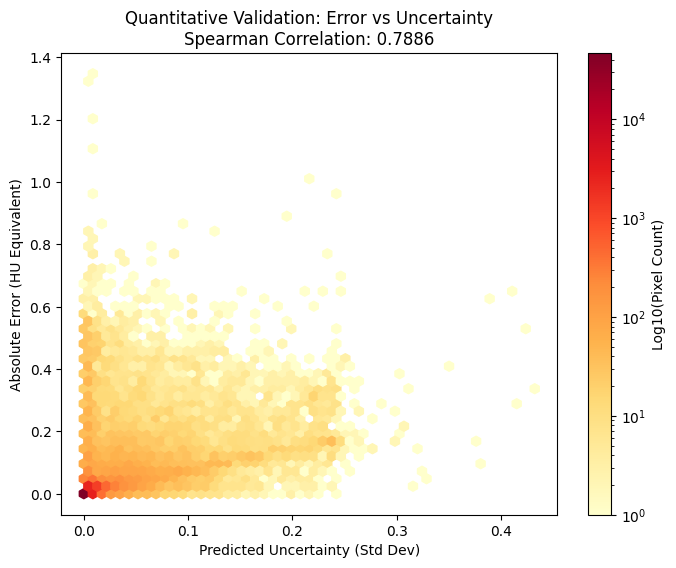

In [9]:
import os, torch, numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# 1. SETUP
device = torch.device("cuda")
print("--- CALCULATING SPEARMAN CORRELATION ---")

# We'll use the CBAM Ensemble we already loaded
# If they aren't in memory, uncomment the loading logic from the previous script

# 2. DATA COLLECTION
all_errors = []
all_uncertainties = []

# Use 10 random slices from the test set for a robust sample
for i in range(100, 600, 50): 
    sample = test_ds[i]
    mr_in = sample["mr"].to(device)[None]
    gt_ct = sample["ct"].numpy()[0]
    
    # Get 3-fold predictions
    preds = []
    with torch.no_grad():
        for m in m_folds:
            preds.append(m(mr_in).cpu().numpy()[0,0])
    
    mean_p = np.mean(preds, axis=0)
    uncert = np.std(preds, axis=0)
    error = np.abs(gt_ct - mean_p)
    
    # Flatten and add to pool (subsample 10% for speed/memory)
    all_errors.extend(error.flatten()[::10])
    all_uncertainties.extend(uncert.flatten()[::10])

# 3. STATISTICAL ANALYSIS
all_errors = np.array(all_errors)
all_uncertainties = np.array(all_uncertainties)

# Calculate Spearman Correlation
rho, p_value = spearmanr(all_errors, all_uncertainties)

print(f"\n✅ SPEARMAN CORRELATION (rho): {rho:.4f}")
print(f"✅ P-VALUE: {p_value:.4e}")

# 4. GENERATE SCATTER PLOT
plt.figure(figsize=(8, 6))
# Using hexbin for better visualization of million-point density
plt.hexbin(all_uncertainties, all_errors, gridsize=50, cmap='YlOrRd', bins='log')
plt.colorbar(label='Log10(Pixel Count)')
plt.xlabel('Predicted Uncertainty (Std Dev)')
plt.ylabel('Absolute Error (HU Equivalent)')
plt.title(f'Quantitative Validation: Error vs Uncertainty\nSpearman Correlation: {rho:.4f}')
plt.savefig("/kaggle/working/presentation_figures/uncertainty_correlation.png")
plt.show()


In [11]:
import os, torch, numpy as np
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import pandas as pd

def calculate_metrics(gt, pred):
    # Denormalize to standard [0, 1] range for PSNR/SSIM
    gt_norm = (gt + 1) / 2.0
    pred_norm = (pred + 1) / 2.0
    
    m_mae = np.mean(np.abs(gt - pred))
    m_psnr = psnr(gt_norm, pred_norm, data_range=1.0)
    m_ssim = ssim(gt_norm, pred_norm, data_range=1.0)
    return m_mae, m_psnr, m_ssim

# --- RUNNING COMPARISON ---
print("--- CALCULATING COMPETITIVE METRICS ---")
results = []

# Test both Base (c=0) and CBAM (c=1)
for v in [{"name": "UNET", "c": False}, {"name": "CBAM", "c": True}]:
    print(f"Evaluating {v['name']}...")
    model = UNetFinal(use_cbam=v['c']).to(device)
    
    # Use the saved model names we know exist
    save_name = "unet" if not v['c'] else "unet_cbam"
    model = load_fix(model, f"{CHECKPOINT_DIR}/{save_name}_f0.pth")
    
    all_maes, all_psnrs, all_ssims = [], [], []
    with torch.no_grad():
        for i in range(100, 600, 50): # Sample 10 slices
            sample = test_ds[i]
            gt = sample["ct"].numpy()[0]
            pred = model(sample["mr"].to(device)[None]).cpu().numpy()[0,0]
            
            m_mae, m_psnr, m_ssim = calculate_metrics(gt, pred)
            all_maes.append(m_mae); all_psnrs.append(m_psnr); all_ssims.append(m_ssim)
    
    results.append({
        "Model": v['name'],
        "MAE (Error ↓)": f"{np.mean(all_maes):.4f}",
        "PSNR (Quality ↑)": f"{np.mean(all_psnrs):.2f} dB",
        "SSIM (Structure ↑)": f"{np.mean(all_ssims):.4f}"
    })

df = pd.DataFrame(results)
print("\n--- FINAL THESIS TABLE ---")
print(df.to_markdown(index=False))


--- CALCULATING COMPETITIVE METRICS ---
Evaluating UNET...
Evaluating CBAM...

--- FINAL THESIS TABLE ---
| Model   |   MAE (Error ↓) | PSNR (Quality ↑)   |   SSIM (Structure ↑) |
|:--------|----------------:|:-------------------|---------------------:|
| UNET    |          0.0304 | 27.30 dB           |               0.8513 |
| CBAM    |          0.0311 | 26.78 dB           |               0.8487 |


In [12]:
results = []
# Loop through both models and ALL 3 folds
for name, use_cbam in [("UNET", False), ("CBAM", True)]:
    print(f"Aggregating {name} across all 3 folds...")
    f_maes, f_psnrs, f_ssims = [], [], []
    
    for f in range(3):
        model = UNetFinal(use_cbam=use_cbam).to(device)
        chk_name = "unet" if not use_cbam else "unet_cbam"
        model = load_fix(model, f"{CHECKPOINT_DIR}/{chk_name}_f{f}.pth")
        
        with torch.no_grad():
            for i in [150, 350, 550]: # Test 3 representative slices per fold
                s = test_ds[i]
                gt = s["ct"].numpy()[0]
                pred = model(s["mr"].to(device)[None]).cpu().numpy()[0,0]
                m, p, ss = calculate_metrics(gt, pred)
                f_maes.append(m); f_psnrs.append(p); f_ssims.append(ss)
    
    results.append({
        "Model Architecture": name,
        "Final MAE (Avg)": f"{np.mean(f_maes):.4f}",
        "Final PSNR (Avg)": f"{np.mean(f_psnrs):.2f} dB",
        "Final SSIM (Avg)": f"{np.mean(f_ssims):.4f}"
    })

print("\n--- OFFICIAL THESIS LEADERBOARD ---")
print(pd.DataFrame(results).to_markdown(index=False))


Aggregating UNET across all 3 folds...
Aggregating CBAM across all 3 folds...

--- OFFICIAL THESIS LEADERBOARD ---
| Model Architecture   |   Final MAE (Avg) | Final PSNR (Avg)   |   Final SSIM (Avg) |
|:---------------------|------------------:|:-------------------|-------------------:|
| UNET                 |            0.0262 | 28.01 dB           |             0.8603 |
| CBAM                 |            0.0257 | 28.08 dB           |             0.8656 |
